# Hands-On AI: From Python Tools to MCP (and beyond)

In this workshop, we'll get hands-on with AI.
Enough with slogans like "AI senses its environment and acts" or "we need to become AI orchestrators" - we're here to see **the real thing** and **touch the code ourselves**.

The good news is that the tools we'll use are designed to keep the code **short and simple**.
And even better - we'll leave concerns like security, scale, and integrations to the engineers, and focus purely on understanding the technology and having fun.

Below is our roadmap for the session:

<img src="images/workshopSteps.PNG">

## Step 1: Installation

<img src="images/roadmap - 1.jpg">

Before we start, let's install the program we need.
In Python, instead of installing **software** → we install a **package**.

To install the packages we'll need later, run the next cell.

What does this command do?

- `pip` - a command for installing packages (we can't use a mouse here, so we type commands 🙂).
- `install` - tells pip what to do (install the packages).
- `langchain` - the first package we install. It helps us build applications with AI models.
- `langchain-openai` – the second package we install. It lets us use OpenAI models through LangChain.

In [ ]:
!pip install langchain langchain-openai


[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 2: Create a Python tool

<img src="images/roadmap - 2.jpg">

Our first building block is a Python tool - something we'll gradually expand and improve throughout the workshop.
(In Python, the formal term for a `Python tool` is a `Python function`).

Our made-up tool, called `mojifuzzle`, will create emojis for us:
hearts ❤️ or stars ⭐ - as many as we want.

Run the code below to create the tool.

Even if you don't know Python, try to guess the logic of the tool - Here are a few helpful terms:

- `def` - short for "define".
- `str` - short for "string" (text).
- `int` - short for "integer" (a whole number).
- `elif` - short for "else if".
- `*` - the sign for multiplication in Python (e.g. 2 * 3 = 6).

### 😊 Don’t worry

You don't need to fully understand the code - it’s enough to get a general idea of what it does.
Also, this is the hardest part - once we're through, the rest is much easier.

In [ ]:
def mojifuzzle(emoji_name: str, count: int) -> str:
    if emoji_name == "heart":
        return "❤️" * count
    elif emoji_name == "star":
        return "⭐" * count
    else:
        return "🤔"

*Note:* If we want to be "extra" and explain our code to others, we can write a note inside `"""` (triple quotes). Python will ignore whatever is inside - but human-beings and AI models can read it (spoiler alert 🙂).

In [ ]:
def mojifuzzle(emoji_name: str, count: int) -> str:
    """
    Create emojis using 'heart' or 'star'.
    """
    if emoji_name == "heart":
        return "❤️" * count
    elif emoji_name == "star":
        return "⭐" * count
    else:
        return "🤔"

Give it a try!

Run the next few cells and see our tool in action:

In [ ]:
mojifuzzle("heart", 10)

In [ ]:
mojifuzzle("star", 2)

In [ ]:
mojifuzzle("moon", 2)

**Try it yourself:** 
Update the cell below and run it to see what happens.

For example:

```python
mojifuzzle("heart", 5)
mojifuzzle("stars", 30)
mojifuzzle("hello", 3)
mojifuzzle("heart", 0)
```

In [6]:
mojifuzzle("heart", 5)

''

### Quick Checkpoint - Any Questions?

# Step 3: Turn the Python Tool into an AI Tool

<img src="images/roadmap - 3.jpg">

Converting a function into an AI tool is very easy. Here is the code:

<img src="images/from python to AI tool.jpg">

In this code, we import the LangChain package (remember: importing a package is like opening an installed software).

The `@tool` tells LangChain:

"This function is a tool that the AI can use".

LangChain then converts the function into structured text that the model can understand:

<img src="images/gif.gif">

<placeholder>

### Optional: 

**Try it yourself:** Run the following cell to see the convertion for yourself:

In [5]:
from langchain_core.utils.function_calling import convert_to_openai_tool
import json

print(json.dumps(convert_to_openai_tool(mojifuzzle), indent=2))

{
  "type": "function",
  "function": {
    "name": "mojifuzzle",
    "description": "Create a sequence of emojis.\nUse 'heart' or 'star'.",
    "parameters": {
      "properties": {
        "emoji_name": {
          "type": "string"
        },
        "count": {
          "type": "integer"
        }
      },
      "required": [
        "emoji_name",
        "count"
      ],
      "type": "object"
    }
  }
}


Checkpoint

## Step 4: Introduce the LLM

<img src="images/roadmap - 4.jpg">

To use an LLM (Large Language Model - a type of AI that can understand and generate text), run the following cell. It:

1. Import ChatOpenAI (Remember: importing is like opening software we've already installed).

2. Create the model:
- Give it a name - `llm` (We could call it anything, like mitzi or david, but we chose a meaningful name so it’s easy to recognize).
- choose a model (`gpt-4o-mini` - a simple and low-cost option).
- provide a key - Python's version for username and password.

In [ ]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini", api_key="WRITE THE KEY HERE")

That is it! just 2 lines and you can talk to an AI model!

Run the next cell and see the response (it will be presented nicely using pretty print):

In [ ]:
response = llm.invoke("Introduce yourself. Which model are you?")
response.pretty_print()

**Try it yourself:**

Use the same code, but change the prompt.

For example:
- "Tell me a joke"
- "Explain what AI is in simple words"

In [ ]:
response = llm.invoke("Tell me a joke")
response.pretty_print()

## Step 5: Introduce the AI Tool to an LLM

<img src="images/roadmap - 5.jpg">

What do you think will happen if we ask our llm:

`please mojifuzzle 3 times with a heart`?

Run the next cell 3-4 times and see what happens.

In [ ]:
response = llm.invoke("Please mojifuzzle 3 times with a heart.")
response.pretty_print()

As you probably noticed, the model improvised: It tried to respond based only on the text prompt and its own reasoning.  
It did **not** use our `mojifuzzle` tool.

So what can we do?

We can introduce our AI tool to the AI model!

In technical language, we use the term "bind", meaning: We will bind the tool to the model and create an improved version. Let's run the next cell and call it `llm_with_tools`. 

In [ ]:
llm_with_tools = llm.bind_tools([mojifuzzle])

Now let's use the same prompt as before:

In [ ]:
response = llm_with_tools.invoke("Please mojifuzzle 3 times with a heart.")
response.pretty_print()

Wait... where are our promised hearts?

Let’s examine the output.

This time, instead of just improvising, the model says:

"I’ve seen a tool that can do this. It’s called `mojifuzzle`.  
If you use it with:

- `emoji_name="heart"`  
- `count=3`

you’ll get exactly what you want".

Not that impressive, right?

Well… let’s see what happens when things get a bit harder:

In [ ]:
response = llm_with_tools.invoke("Please mojifuzzle the symbol of love for the number of sides in a triangle. Make sure to provide only a single output.")
response.pretty_print()

## Recap

Let’s recap what we’ve done:

1. Created a Python function (`mojifuzzle`).
2. Turned it into an AI tool using `@tool`.
3. "Created" an LLM.
4. Connected an LLM using `bind`.

👉 What we discovered:
- The LLM can now *recognize* when to use the tool,  
- But it still does NOT run the tool by itself.

That’s exactly what we’ll fix next.

Check poinnt

<hr>

## The next stage: Letting AI Actually Use the Tool 

To make this work end-to-end, instead of an LLM - we need an **agent**: an agent uses an LLM **together** with tools and logic to take actions.

This is how we want our agent to work:

<img src="images/our missing piece.jpg">

But we will use something better -  a ReAct Agent: if we add an edge from the tool back to the LLM, the model can use the tool’s result and decide whether another step is needed. This creates a pattern called ReAct, which is essentially letting the model think again after using a tool.
We will use Claude Desktop, which operates in a ReAct-like manner.

<img src="images/orchestrating.jpg">

Let's demonstrate with the demo:

### Step 1: Create an MCP server

We will wrap our tool in a small server:

<img src="images/from tool to mcp server.jpg">

Let's copy the code:

```python
from mcp.server.fastmcp import FastMCP

mcp = FastMCP("Mojifuzzle server")

@mcp.tool()
def mojifuzzle(emoji_name: str, count: int) -> str:
    """
    Create emojis using 'heart' or 'star'.
    """
    if emoji_name == "heart":
        return "❤️" * count
    elif emoji_name == "star":
        return "⭐" * count
    else:
        return "🤔"

if __name__ == "__main__":
    mcp.run()
```

### Step 2: Run it as a separate program

Place this code in a Python file and run it outside the notebook.

### Step 3: Connect from an MCP client

Now we can connect to it using an MCP client like Claude Desktop and use it.

## Optional: Build Your Own Agent from Scratch

If you're curious how to build the state machine we just discussed using LangGraph, here's how to do it:

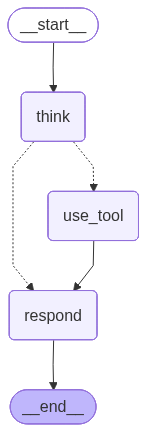

In [ ]:
from langgraph.graph import StateGraph
from IPython.display import Image

# Define the state
class AgentState(dict):
    pass

# Step 1: Ask the model what to do
def think(state):
    response = llm_with_tools.invoke(state["input"])
    return {"response": response}

# Step 2: Decide if we need to use a tool
def should_use_tool(state):
    if state["response"].tool_calls:
        return "use_tool"
    return "respond"

# Step 3: Execute the tool
def use_tool(state):
    tool_call = state["response"].tool_calls[0]
    tool_output = mojifuzzle.invoke(tool_call["args"])
    
    return {
        "tool_output": tool_output
    }

# Step 4: Return final answer
def respond(state):
    if "tool_output" in state:
        return {"output": state["tool_output"]}
    
    return {"output": state["response"].content}

# Build graph
graph = StateGraph(AgentState)

graph.add_node("think", think)
graph.add_node("use_tool", use_tool)
graph.add_node("respond", respond)

graph.set_entry_point("think")

graph.add_conditional_edges(
    "think",
    should_use_tool,
    {
        "use_tool": "use_tool",
        "respond": "respond"
    }
)

graph.add_edge("use_tool", "respond")

app = graph.compile()

# Visualize the graph
Image(app.get_graph().draw_mermaid_png())

Now run the model:

In [ ]:
# Run it
result = app.invoke({
    "input": "Please mojifuzzle 3 hearts"
})

print(result["output"])